In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from pybedtools import BedTool
plt.style.use('seaborn-white')
plt.rcParams["image.cmap"] = "Set3"
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
indir = '../output/sailor/annotate/'


In [2]:
files = [f.split('.')[0] for f in os.listdir(indir)]

In [3]:
pval_thres = (1e-5)

In [4]:
region_count = []

for f in files:
    df = pd.read_csv(os.path.join(indir, f'{f}.filtered.annotate.bed'), sep = '\t',
                    names = ['chrom', 'start', 'end', 'score', 'edit/coverage', 'strand',
                           'geneid', 'genename', 'region', 'detail'
                           ])
    region_count.append(df.loc[df['score']>(1-pval_thres), 'region'].value_counts())
region_count_df = pd.DataFrame(region_count, index = files)

Text(0, 0.5, '# significant edits (pval<1e-05)')

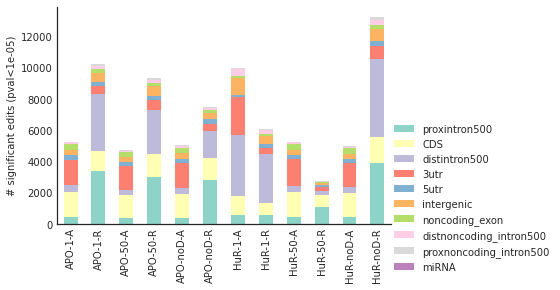

In [5]:
region_count_df.sort_index().plot.bar(stacked = True)
plt.legend(bbox_to_anchor = (1.5, 0.5))
sns.despine()
plt.ylabel(f'# significant edits (pval<{pval_thres})')

# Find HuR unique edits

In [6]:

huR_files = [f for f in files if 'HuR' in f]

In [7]:
huR_files

['HuR-50-R', 'HuR-50-A', 'HuR-1-A', 'HuR-noD-R', 'HuR-noD-A', 'HuR-1-R']

In [8]:
huR_unique_region_count = []
for f in huR_files:
    huR_bed = BedTool(os.path.join(indir, f'{f}.filtered.annotate.bed')).filter(lambda x: float(x[3])>(1-pval_thres))
    apo_name = f.replace('HuR', 'APO')
    apo_bed = BedTool(os.path.join(indir, f'{apo_name}.filtered.annotate.bed')).filter(lambda x: float(x[3])>(1-pval_thres))
    
    huR_unique = huR_bed.intersect(apo_bed, s = True, v = True).to_dataframe(names = ['chrom', 'start', 'end', 'score', 'edit/coverage', 'strand',
                           'geneid', 'genename', 'region', 'detail'
                           ])
    
    huR_unique_region_count.append(huR_unique['region'].value_counts())
huR_unique_region_count_df = pd.DataFrame(huR_unique_region_count, index = huR_files)

***** WARNING: File /scratch/hsher/29178658.tscc-mgr7.local/pybedtools.4g9o1m3k.tmp has inconsistent naming convention for record:
GL000220.1	106344	106345	1.0	38,100	+	intergenic	intergenic	intergenic	intergenic

***** WARNING: File /scratch/hsher/29178658.tscc-mgr7.local/pybedtools.4g9o1m3k.tmp has inconsistent naming convention for record:
GL000220.1	106344	106345	1.0	38,100	+	intergenic	intergenic	intergenic	intergenic

***** WARNING: File /scratch/hsher/29178658.tscc-mgr7.local/pybedtools.8rbwyjsw.tmp has inconsistent naming convention for record:
GL000195.1	154980	154981	0.99999988	5,14	+	intergenic	intergenic	intergenic	intergenic

***** WARNING: File /scratch/hsher/29178658.tscc-mgr7.local/pybedtools.8rbwyjsw.tmp has inconsistent naming convention for record:
GL000195.1	154980	154981	0.99999988	5,14	+	intergenic	intergenic	intergenic	intergenic

***** WARNING: File /scratch/hsher/29178658.tscc-mgr7.local/pybedtools.mnx6ev_j.tmp has inconsistent naming convention for record:
GL0

Text(0.5, 1.0, 'HuR \\cap \\stcomp{APO}')

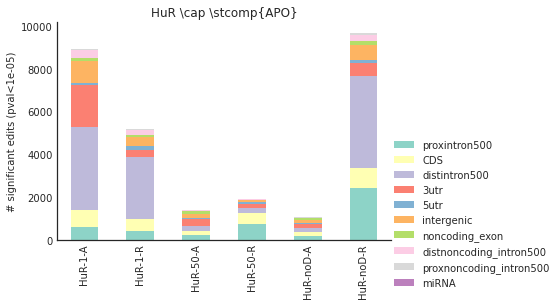

In [9]:
huR_unique_region_count_df.sort_index().plot.bar(stacked = True)
plt.legend(bbox_to_anchor = (1.5, 0.5))
sns.despine()
plt.ylabel(f'# significant edits (pval<{pval_thres})')
plt.title('HuR \cap \stcomp{APO}')